## Week 4 Assignment - Data Visualization

### Objective: After all four analysis tasks you have conducted for this company EcoTrek Solutions, you decide to use data visualizations to show your manager the analysis results. Specifically, you will write Python code to visualize:

1. the correlation between the sales performance of GreenTote and the temperature, using the data provided in the second assignment

2. the number of customer reviews in each of the three categories: positive, neutral, and negative

3. word cloud of customers' reviews from three categories: positive, neutral, and negative

## 1. Correlation between GreenTote and Temperature

In [12]:
# Import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# Bring over Temperature and Sales Data Dictionaries from Assignment 2
# Dictionary for temperature in °F
Temperature = {
    "January": 40,
    "February": 45,
    "March": 55,
    "April": 65,
    "May": 75,
    "June": 85,
    "July": 90,
    "August": 88,
    "September": 86,
    "October": 80,
    "November": 70,
    "December": 60
}

In [5]:
# Dictionary for GreenTote sales
GreenTote_Sales = {
    "January": 87500,
    "February": 100625,
    "March": 115725,
    "April": 132075,
    "May": 148875,
    "June": 164500,
    "July": 172725,
    "August": 185800,
    "September": 180900,
    "October": 170000,
    "November": 165000,
    "December": 160000
}

In [16]:
## Combine dictionaries into DataFrame

df = pd.DataFrame({"Sales": GreenTote_Sales, "Temperature": Temperature})
print(df)

            Sales  Temperature
January     87500           40
February   100625           45
March      115725           55
April      132075           65
May        148875           75
June       164500           85
July       172725           90
August     185800           88
September  180900           86
October    170000           80
November   165000           70
December   160000           60


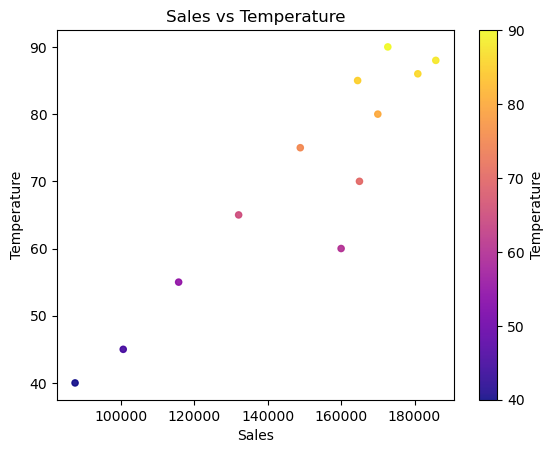

In [19]:
# Create Scatter Plot using Pandas
df.plot(kind='scatter', x='Sales', y='Temperature', c='Temperature', colormap='plasma', alpha=0.9)
plt.xlabel('Sales')
plt.ylabel('Temperature')
plt.title('Sales vs Temperature')
plt.show()

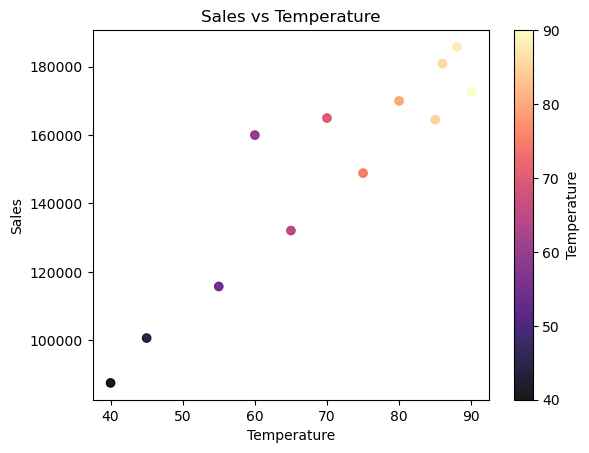

In [23]:
# Using Matplotlib
plt.scatter(df['Temperature'], df['Sales'], c=df['Temperature'], cmap='magma', alpha=0.9)
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.title('Sales vs Temperature')
plt.colorbar(label='Temperature')
plt.show()

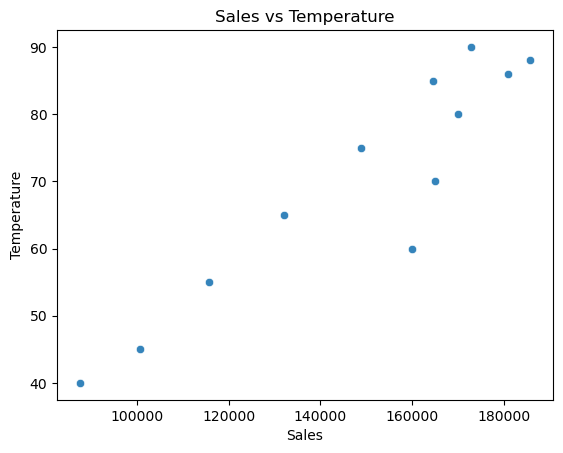

In [25]:
# Using Seaborn
sns.scatterplot(x='Sales', y='Temperature', data=df, alpha=0.9)
plt.xlabel('Sales')
plt.ylabel('Temperature')
plt.title('Sales vs Temperature')
plt.show()

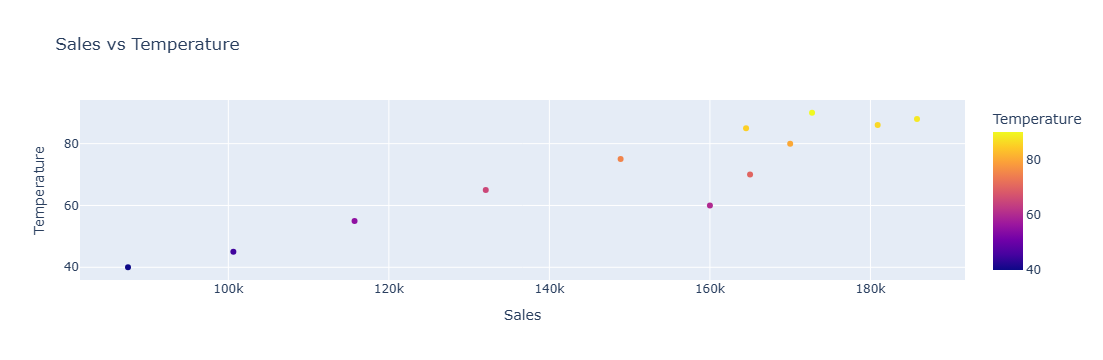

In [27]:
# Using Plotly
fig = px.scatter(df, x='Sales', y='Temperature', color='Temperature', title='Sales vs Temperature')
fig.show()

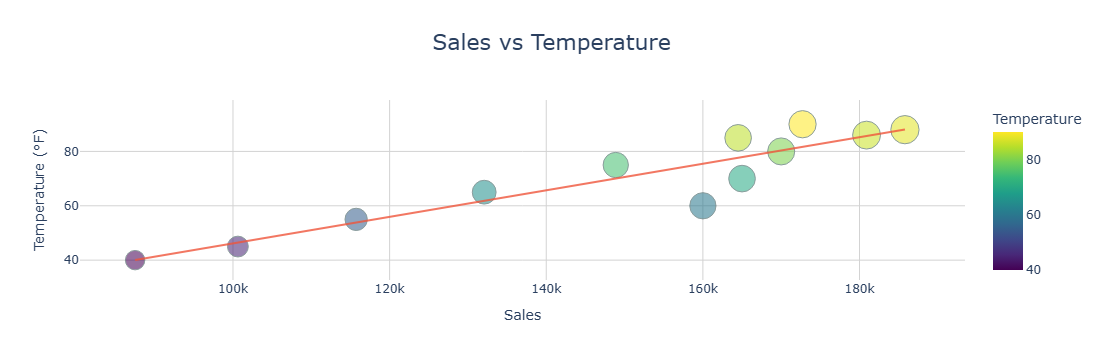

In [30]:
# I decided to use Plotly and make a more dynamic chart

fig = px.scatter(
    df,
    x="Sales",
    y="Temperature",
    color="Temperature",                 # gradient coloring by temperature
    size="Sales",                        # bubble size based on sales
    hover_data=df.columns,               # show all columns on hover
    trendline="ols",                     # add regression line
    color_continuous_scale="Viridis",    
    title="Sales vs Temperature"
)

# Update layout for better readability
fig.update_layout(
    title=dict(x=0.5, font=dict(size=22)),    # center & enlarge title
    xaxis_title="Sales",
    yaxis_title="Temperature (°F)",
    plot_bgcolor="white",                     # clean background
    xaxis=dict(showgrid=True, gridcolor="lightgray"),
    yaxis=dict(showgrid=True, gridcolor="lightgray"),
)

# Improve marker styling
fig.update_traces(
    marker=dict(line=dict(width=1, color="DarkSlateGrey")),
    opacity=0.8
)

fig.show()


## This chart with the treadline shows a clear postitive correlation between higher temperature and higher sales

## 2. the number of customer reviews in each of the three categories: positive, neutral, and negative

In [32]:
# Read in customer review data from Assignment 3

df = pd.read_csv("Danut_George_sentiment.csv")
df.head()

                                              Review  Rating sentiment
0  I expected better quality for the price; not w...       1  positive
1  It cleans easily after outdoor adventures; a b...       5  positive
2   Handles are uncomfortable and dig into my hands.       1  negative
3  Lightweight and easy to carry during hikes and...       5  positive
4    The handles are sturdy and comfortable to hold.       5  positive

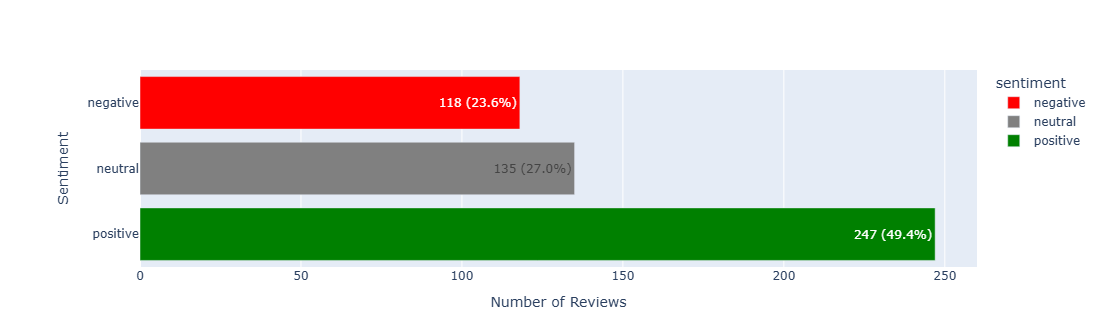

In [48]:
# Group by sentiment and count reviews
sentiment_counts = (df.groupby("sentiment")["Review"].count().reset_index().rename(columns={"Review": "Count"}))

# Add percentage column
total = sentiment_counts["Count"].sum()
sentiment_counts["Percent"] = (sentiment_counts["Count"] / total * 100).round(1)

# Create a combined text column for display
sentiment_counts["Label"] = sentiment_counts["Count"].astype(str) + " (" + sentiment_counts["Percent"].astype(str) + "%)"

# Plot horizontal bars
fig = px.bar(
    sentiment_counts,
    x="Count",
    y="sentiment",
    orientation="h",
    color="sentiment",
    text="Label",
    color_discrete_map={"positive": "green", "neutral": "gray", "negative": "red"}
)

fig.update_traces(textposition="auto", textfont=dict(size=12))
fig.update_layout(width=750, height=320, margin=dict(l=140, r=120, t=70, b=50))
fig.update_layout(xaxis_title="Number of Reviews", yaxis_title="Sentiment")

fig.show()

## 3. word cloud of customers' reviews from three categories: positive, neutral, and negative

In [39]:
## Install and import Word Clound
!pip install wordcloud matplotlib
from wordcloud import WordCloud

     -------------------------------------- 299.8/299.8 kB 1.9 MB/s eta 0:00:00


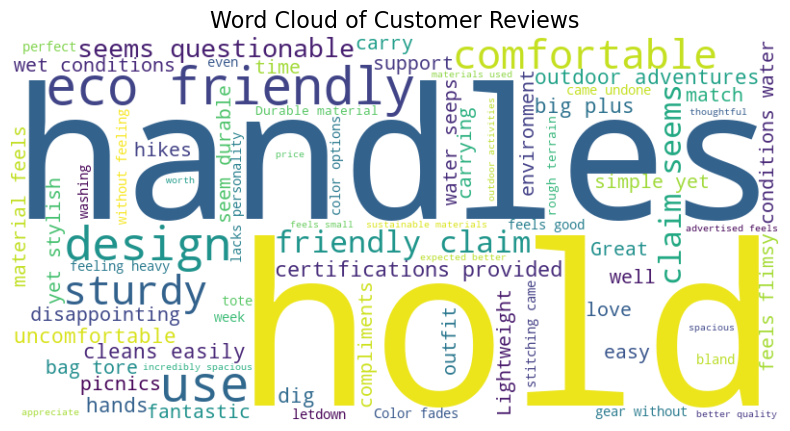

In [41]:
## Create Word Cloud

# Combine all reviews into one string
text = " ".join(review for review in df["Review"].astype(str))


# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",   # nice color map
    max_words=100,        # top 100 words
    contour_color="steelblue",
    contour_width=2
).generate(text)

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews", fontsize=16)
plt.show()